In [1]:
# STEP 1 - Load Data
# • Import pandas
import pandas as pd

# • Load mushrooms.csv
a = pd.read_csv("mushrooms.csv")

# • Print:

# ● shape
print(a["cap-shape"])

# ● column names
print(a.columns)

# ● first 5 rows
print(a.head())

0       x
1       x
2       b
3       x
4       x
       ..
8119    k
8120    x
8121    f
8122    k
8123    x
Name: cap-shape, Length: 8124, dtype: object
Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    

In [2]:
# STEP 2 - Basic Exploration
# Print:
# data['class'].value_counts()
print(a['class'].value_counts())

# Question:
# Are there more edible or poisonous mushrooms?
# There are mostly edible mushrooms.

class
e    4208
p    3916
Name: count, dtype: int64


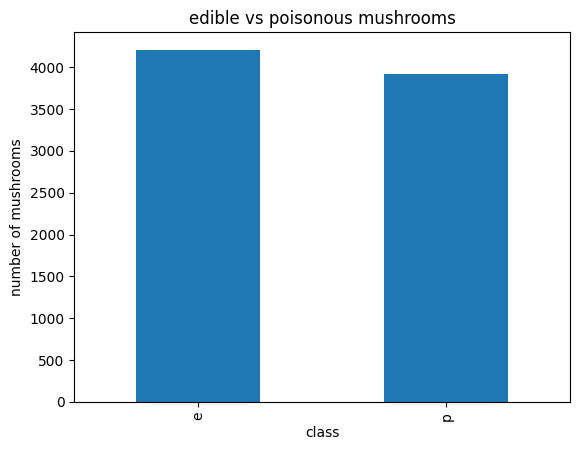

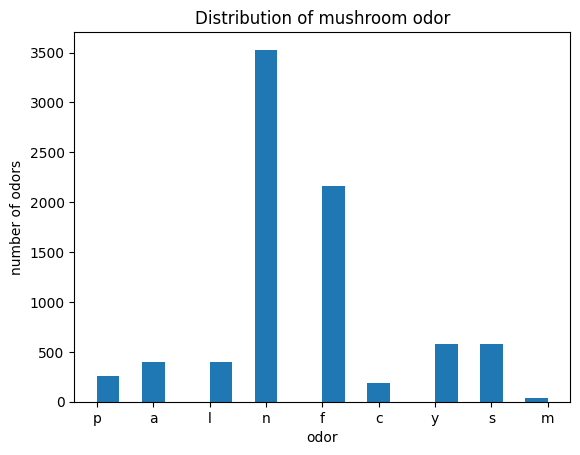

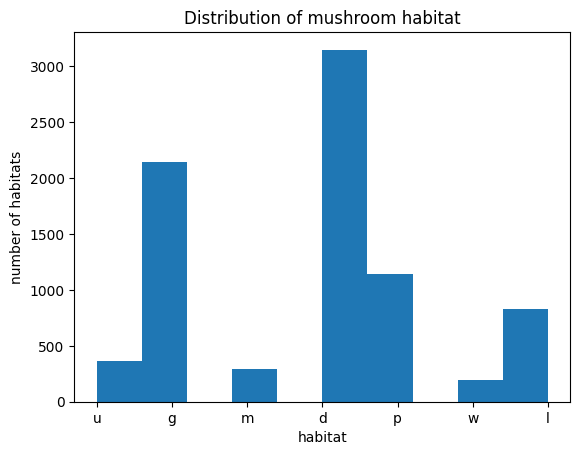

In [3]:
# STEP 3 - Plot Graphs
# Make 3 graphs:
# 1. Count of edible vs poisonous mushrooms
import matplotlib.pyplot as plt
a["class"].value_counts().plot(kind = "bar")
plt.title("edible vs poisonous mushrooms")
plt.xlabel("class")
plt.ylabel("number of mushrooms")
plt.show()


# 2. Distribution of mushroom odor
plt.hist(a["odor"], bins = 20)
plt.xlabel("odor")
plt.ylabel("number of odors")
plt.title("Distribution of mushroom odor")
plt.show()

# 3. Distribution of mushroom habitat
plt.hist(a["habitat"], bins = 10)
plt.xlabel("habitat")
plt.ylabel("number of habitats")
plt.title("Distribution of mushroom habitat")
plt.show()

In [17]:
# STEP 4 - Encode Data
# All columns are categorical.
# Use LabelEncoder to convert all columns into numbers.
from sklearn.preprocessing import LabelEncoder
h = ["class", "odor", "bruises", "cap-surface", "cap-shape", "gill-attachment", "habitat", "stalk-surface-below-ring", "gill-spacing", "gill-size", "gill-color", "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color", "ring-number", "ring-type", "spore-print-color", "population", "cap-color"]
e = LabelEncoder()
encoded = a.copy()
encoded[h] = a[h].apply(e.fit_transform)

In [18]:
encoded

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,3,2,4,0,5,0,0,0,11,...,2,5,5,0,1,1,4,0,1,2
8120,0,5,2,4,0,5,0,0,0,11,...,2,5,5,0,0,1,4,0,4,2
8121,0,2,2,4,0,5,0,0,0,5,...,2,5,5,0,1,1,4,0,1,2
8122,1,3,3,4,0,8,1,0,1,0,...,1,7,7,0,2,1,0,7,4,2


In [21]:
# STEP 5 - Feature / Target Split
# Target:
# y = class
from sklearn.model_selection import train_test_split
y = encoded["class"]

# Features:
# X = all other columns

x = encoded.drop("class", axis = 1)

In [20]:
# STEP 6 - Train Test Split
# Use:
# test_size = 0.2
# stratify = y
# random_state = 3
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 3)

In [24]:
# STEP 7 - Train Model
# Use:
# DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np
x = encoded[["odor", "cap-color"]]
y = encoded["class"]
model = LogisticRegression()
model.fit(x, y)

# Train the model.
print("predicted mushroom", model.predict([[1, 3]]))
print("model", model.score(x_test, y_test))

predicted mushroom [1]
model 0.6535384615384615


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [25]:
# STEP 8 - Evaluate
# Print:
# Training Accuracy

# Test Accuracy
from sklearn.metrics import confusion_matrix
pred = model.predict(x_test)
l = confusion_matrix(y_test, pred)
print(l)

[[726 116]
 [447 336]]


In [9]:
# STEP 9 - Confusion Matrix
# Print the confusion matrix.
# Explain what each value means:

# True Positive

# True Negative

# False Positive

# False Negative


In [26]:
import pandas as pd
data = pd.DataFrame({
   "game" : ["Minecraft", "Fortnite", "Roblox", "GTA V", "Mario Kart"],
   "genre": ["Sandbox", "Battle Royale", "Sandbox", "Action", "Racing"],
   "price" : [30, 0, 0, 40, 50],
   "rating" : [9.5, 8.5, 8.0, 9.2, 9.0],
   "number_of_players" : [140, 80, 70, 75, 45]
})
print(data)

         game          genre  price  rating  number_of_players
0   Minecraft        Sandbox     30     9.5                140
1    Fortnite  Battle Royale      0     8.5                 80
2      Roblox        Sandbox      0     8.0                 70
3       GTA V         Action     40     9.2                 75
4  Mario Kart         Racing     50     9.0                 45


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplot(2, 2, figsize = (8, 8))
sns.histplot(a["rating"], bins = 5, ax = axes[0,0])
axes[0,0].set_title("ratings graph")

sns.scatterplot(x = "price", y = "rating", data = data, ax = axes[0,1])
axes[0,1].set_title("price scatter plot")
plt.show()

TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

<Figure size 640x480 with 0 Axes>